In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

In [ ]:
# Load dataset
df = pd.read_csv("AnnualNO2diffusionBNG_gdb_5635812497483740389.csv")

# Preview first rows
df.head()
# ------ OBSERVATIONS ------
# The dataset includes columns for location, coordinates, current and historical NO2 diffusion values.


,OBJECTID,SiteID,Location,Year,Count,Historical_annual_data,NO2 2024,Annual mean NO2 concentration μg m3,Survey,Current_,x,y
0,1,2,Colston Avenue,2024,10.0,"2010: 79.4, 2011: 78.8, 2012: 66.8, 2013: 68.7...",38.4,38.4,Roadside (DT),Yes,-289075.818144,6.702097e+06
1,2,3,Blackboy Hill,2024,12.0,"2010: 46, 2011: 36.6, 2012: 37.7, 2013: 41.2, ...",29.0,29.0,Roadside (DT),Yes,-290988.199331,6.704714e+06
2,3,4,Three Lamps,2024,12.0,"2010: 62.3, 2011: 59.8, 2012: 58.4, 2013: 60.6...",30.7,30.7,Roadside (DT),Yes,-287018.565740,6.700249e+06
3,4,5,Bedminster Parade,2024,12.0,"2010: 66.6, 2011: 57.2, 2012: 54.6, 2013: 58.7...",34.9,34.9,Roadside (DT),Yes,-288906.606436,6.699999e+06
4,5,10,Bath Road,2024,12.0,"2010: 68.2, 2011: 62.3, 2012: 58.4, 2013: 61.5...",30.3,30.3,Roadside (DT),Yes,-284908.842563,6.699589e+06


In [ ]:
#Visualising historical annual data for the first row to see the structure of the data
pd.set_option('display.max_colwidth', None)
df.loc[0, "Historical_annual_data"]



'2010: 79.4, 2011: 78.8, 2012: 66.8, 2013: 68.7, 2014: 67.7, 2015: 69.2, 2016: 66.1, 2017: 63.1, 2018: 58.2, 2019: 53.7, 2020: 36.9, 2021: 40.1, 2022: 40.3, 2023: 39, 2024: 38.4'

In [7]:
print(df.shape)
print(df.columns)
print(df.info())

(2028, 12)
Index(['OBJECTID', 'SiteID', 'Location', 'Year', 'Count',
       'Historical_annual_data', 'NO2 2024',
       'Annual mean NO2 concentration μg m3', 'Survey', 'Current_', 'x', 'y'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2028 entries, 0 to 2027
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   OBJECTID                             2028 non-null   int64  
 1   SiteID                               2028 non-null   int64  
 2   Location                             2027 non-null   object 
 3   Year                                 2028 non-null   int64  
 4   Count                                2017 non-null   float64
 5   Historical_annual_data               2028 non-null   object 
 6   NO2 2024                             202 non-null    float64
 7   Annual mean NO2 concentration μg m3  2017 non-null   float64
 8   Survey       

In [ ]:
df.describe()

,OBJECTID,SiteID,Year,Count,NO2 2024,Annual mean NO2 concentration μg m3,x,y
count,2028.000000,2028.000000,2028.000000,2017.000000,202.000000,2017.000000,2028.000000,2.028000e+03
mean,1014.500000,382.071992,2017.784024,12.506693,25.594059,36.228706,-288296.145047,6.702813e+06
std,585.577493,209.703587,4.622258,6.114165,6.587072,12.256813,3429.174349,3.202410e+03
min,1.000000,2.000000,2010.000000,1.000000,11.200000,11.200000,-300244.658920,6.693403e+06
25%,507.750000,239.000000,2014.000000,11.000000,21.400000,27.200000,-289769.578448,6.700100e+06
50%,1014.500000,423.000000,2018.000000,12.000000,24.550000,34.600000,-288086.580168,6.702764e+06
75%,1521.250000,559.000000,2022.000000,12.000000,29.075000,43.100000,-286284.930702,6.704468e+06
max,2028.000000,711.000000,2024.000000,48.000000,50.800000,102.600000,-280107.191203,6.711867e+06


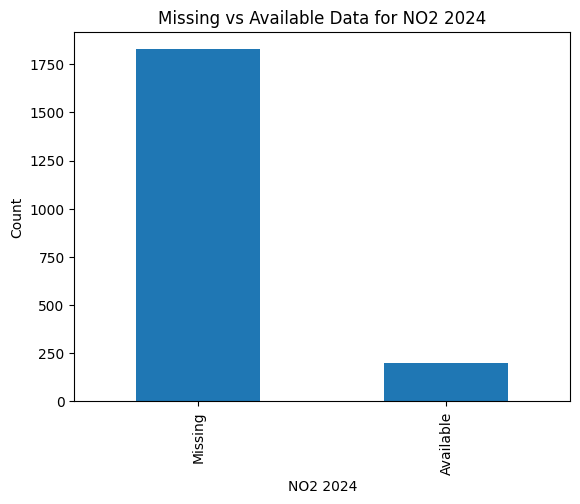

90.03944773175543


In [ ]:
df.isnull().sum() #minimal missing values, mainly coming from NO2 2024 column
#df.duplicated().sum() there were no duplicates in the dataset so hopefully no extensive data cleaning is required.

#investigating missing values in NO2 2024 column
df["NO2 2024"].isnull().value_counts().rename({False: "Available", True: "Missing"}).plot(kind="bar")

plt.title("Missing vs Available Data for NO2 2024")
plt.ylabel("Count")

plt.show()


missing_percentage = df["NO2 2024"].isnull().mean() * 100
print(missing_percentage) #90% missing suggests that we should potentially drop this column?




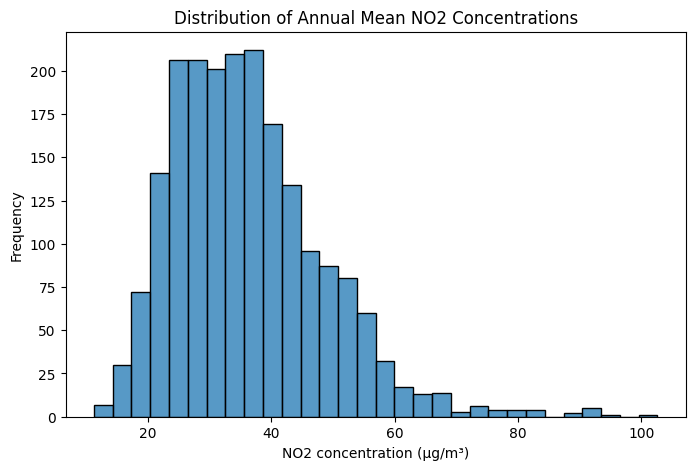

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Annual mean NO2 concentration μg m3"], bins=30)
plt.title("Distribution of Annual Mean NO2 Concentrations")
plt.xlabel("NO2 concentration (μg/m³)")
plt.ylabel("Frequency")
plt.show()


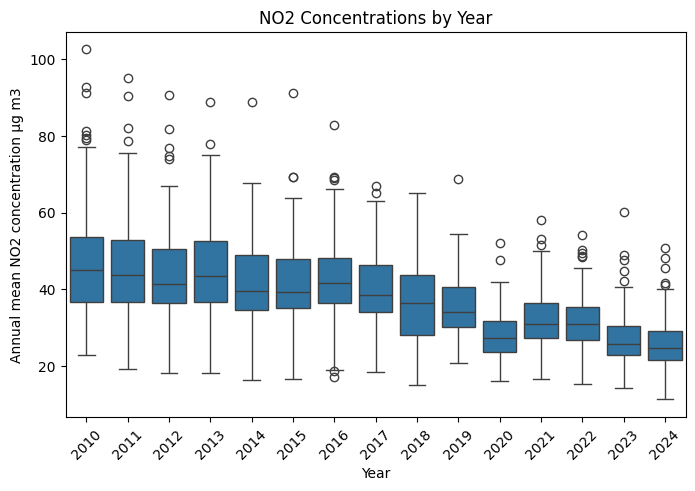

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Year", y="Annual mean NO2 concentration μg m3", data=df)

plt.title("NO2 Concentrations by Year")
plt.xticks(rotation=45)
plt.show()
#shows downward trend in NO2 concentrations over the years, with some outliers in certain years. This could indicate improvements in air quality or changes in measurement locations over time.
#Outliers could be investigated further to understand if they are due to specific events, measurement errors, or other factors.

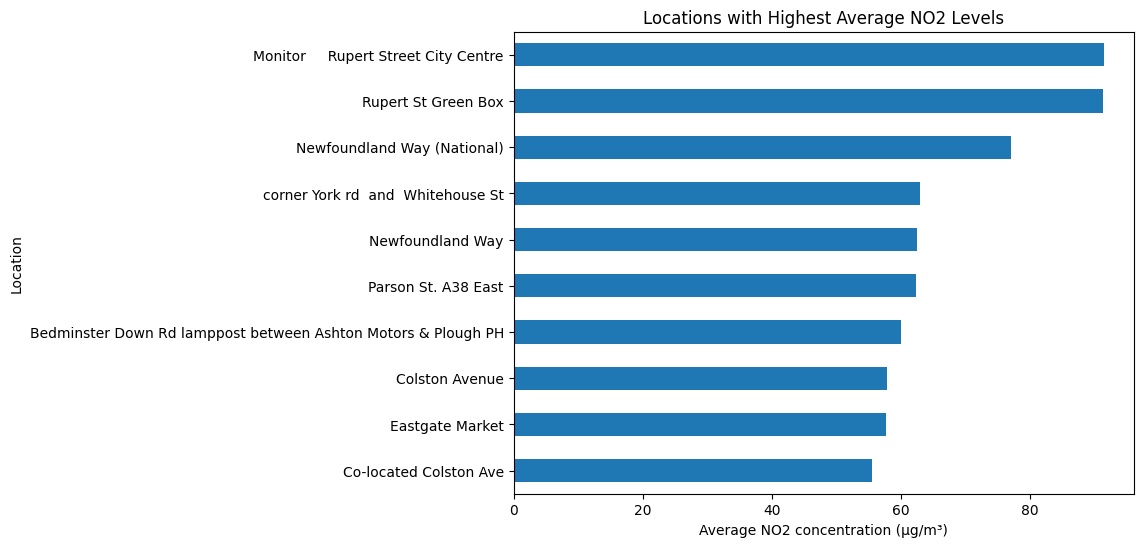

In [16]:
top_locations = df.groupby("Location")["Annual mean NO2 concentration μg m3"].mean().sort_values(ascending=False).head(10)

top_locations.plot(kind="barh", figsize=(8,6))

plt.title("Locations with Highest Average NO2 Levels")
plt.xlabel("Average NO2 concentration (μg/m³)")
plt.ylabel("Location")
plt.gca().invert_yaxis()

plt.show()



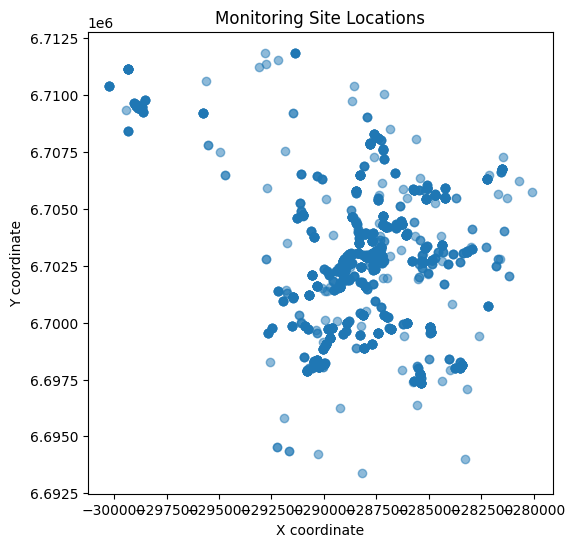

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(df["x"], df["y"], alpha=0.5)

plt.title("Monitoring Site Locations")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

plt.show()


In [ ]:
df["Year"].unique() #showing the range of years in the dataset
df.groupby("Location")["Year"].nunique()
df.groupby("Location")["Year"].nunique().value_counts() #shows how many years of data we have for each location



Year
1     89
4     89
15    56
2     35
8     23
6     17
3     16
5      9
7      9
11     7
10     6
14     4
12     1
Name: count, dtype: int64

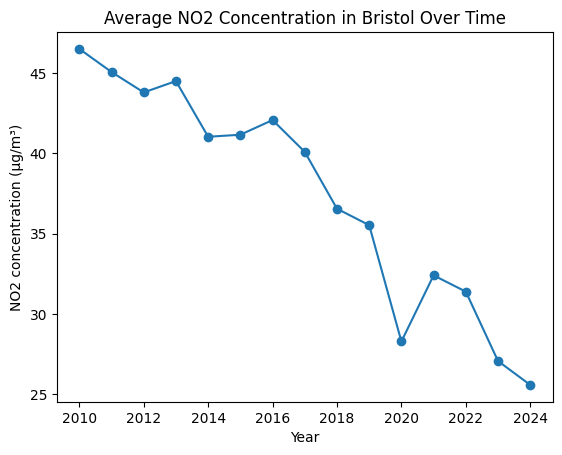

In [15]:
df.groupby("Year")["Annual mean NO2 concentration μg m3"].mean().plot(marker='o')

plt.title("Average NO2 Concentration in Bristol Over Time")
plt.ylabel("NO2 concentration (μg/m³)")

plt.show()
